In [70]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [71]:
ticker = "AMZN"
data = yf.download(ticker,start="2015-01-01", end="2023-12-31")
prices = data["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed


<Axes: title={'center': 'AMZN Close Price'}, xlabel='Date'>

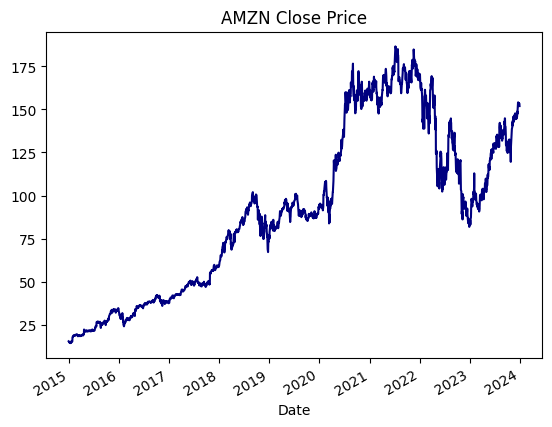

In [72]:
prices.plot(title=f"{ticker} Close Price", color="navy")

<Axes: title={'center': 'Daily Log Returns'}, xlabel='Date'>

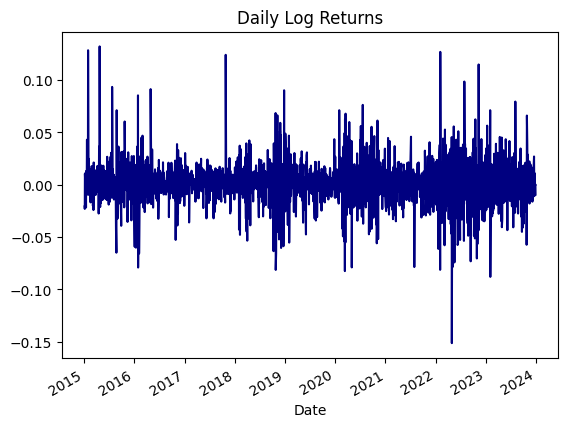

In [73]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.plot(title="Daily Log Returns", color="navy")

In [74]:
trading_days = 252

mu = log_returns.mean() * trading_days
sigma = log_returns.std() * np.sqrt(trading_days)

print(f"Annualized mu: {mu.item():.4f}")
print(f"Annualized sigma: {sigma.item():.4f}")

Annualized mu: 0.2547
Annualized sigma: 0.3313


# Simulate/Generate price paths

In [75]:
def simulate_gbm(S0, mu, sigma, T, steps, n_paths, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / steps
    Z = rng.standard_normal((steps, n_paths))
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.vstack([np.zeros(n_paths), np.cumsum(increments, axis=0)])
    return S0 * np.exp(log_paths)

In [76]:
S0 = float(prices.iloc[0])
paths = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=1, steps=252, n_paths=1000, seed=42)

In [77]:
print(f"Simulated {paths.shape[1]} paths over {paths.shape[0]} steps")
print(f"Terminal price — mean: {paths[-1].mean():.2f}, std: {paths[-1].std():.2f}")

Simulated 1000 paths over 253 steps
Terminal price — mean: 19.96, std: 7.04


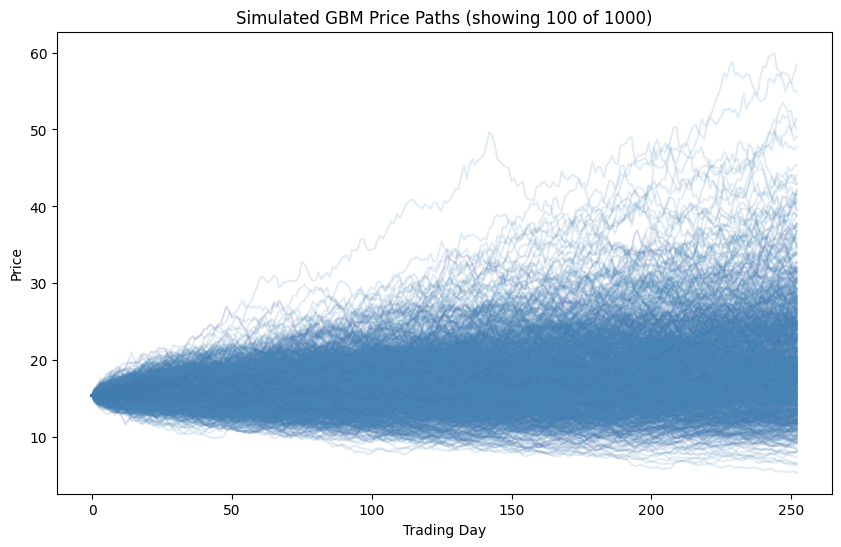

In [78]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :100], alpha=0.15, color='navy')
plt.title(f"Simulated GBM Price Paths (showing 100 of {paths.shape[1]})")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.plot(paths[:, 100:], alpha=0.15, color='steelblue')
plt.show()

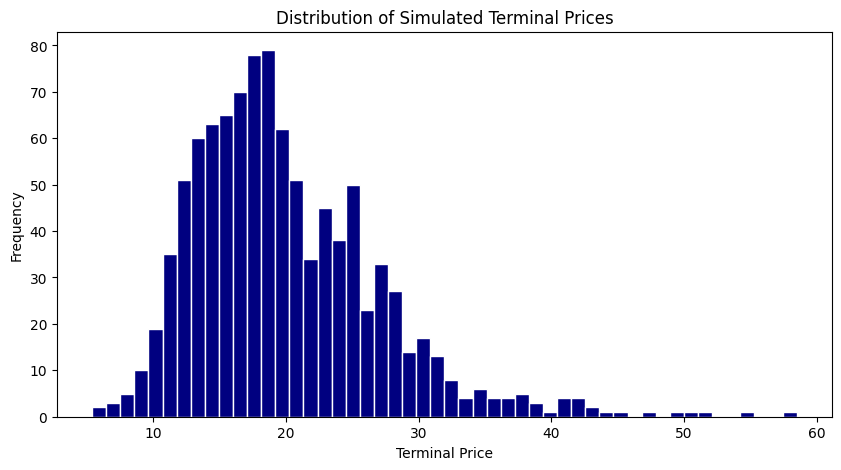

In [79]:
plt.figure(figsize=(10, 5))
plt.hist(paths[-1], bins=50, color='navy', edgecolor='white')
plt.title("Distribution of Simulated Terminal Prices")
plt.xlabel("Terminal Price")
plt.ylabel("Frequency")
plt.show()

In [80]:
sim_returns = np.diff(np.log(paths), axis=0).flatten()

In [81]:
real_skew = stats.skew(log_returns)
real_kurt = stats.kurtosis(log_returns)  # excess kurtosis: 0 = normal, >0 = fat tails

sim_skew = stats.skew(sim_returns)
sim_kurt = stats.kurtosis(sim_returns)

print("Real returns       — skew: {:.4f}, excess kurtosis: {:.4f}".format(real_skew, real_kurt))
print("Simulated returns  — skew: {:.4f}, excess kurtosis: {:.4f}".format(sim_skew, sim_kurt))

Real returns       — skew: 0.1874, excess kurtosis: 5.8396
Simulated returns  — skew: 0.0079, excess kurtosis: 0.0191


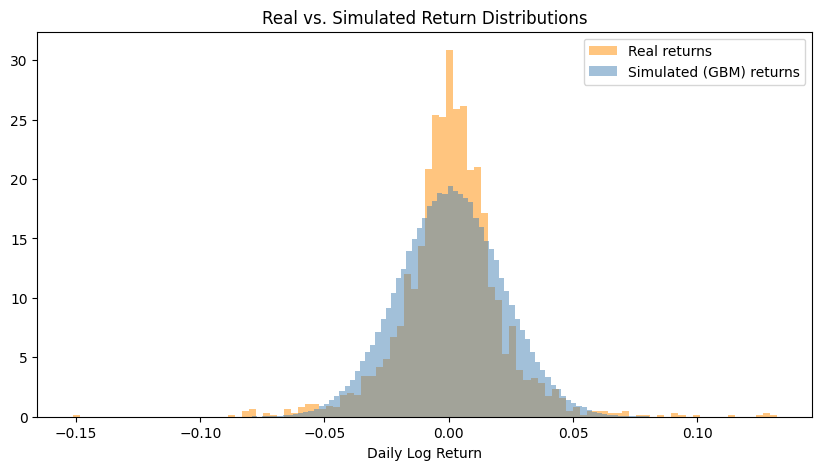

In [82]:
plt.figure(figsize=(10, 5))
plt.hist(log_returns, bins=100, density=True, alpha=0.5, label="Real returns", color='darkorange')
plt.hist(sim_returns, bins=100, density=True, alpha=0.5, label="Simulated (GBM) returns", color='steelblue')
plt.legend()
plt.title("Real vs. Simulated Return Distributions")
plt.xlabel("Daily Log Return")
plt.show()

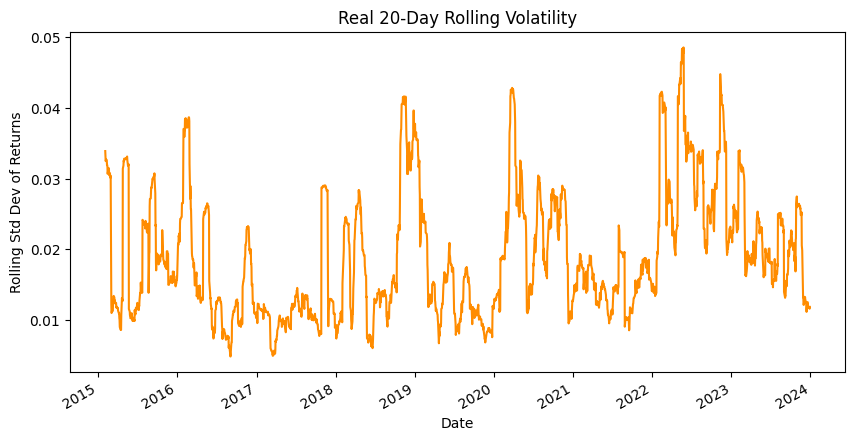

In [83]:
rolling_vol_real = log_returns.rolling(20).std()

plt.figure(figsize=(10, 5))
rolling_vol_real.plot(color='darkorange')
plt.title("Real 20-Day Rolling Volatility")
plt.ylabel("Rolling Std Dev of Returns")
plt.show()

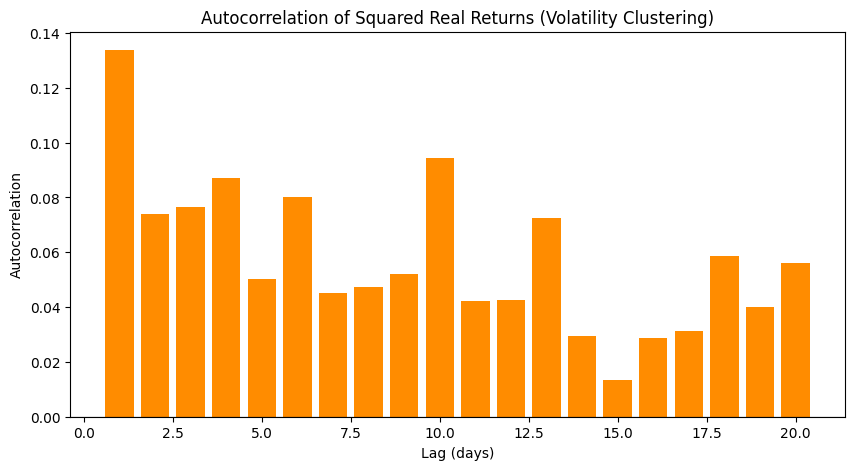

In [84]:
sq_real = log_returns ** 2
lags = 20
autocorrs = [sq_real.autocorr(lag=i) for i in range(1, lags + 1)]

plt.figure(figsize=(10, 5))
plt.bar(range(1, lags + 1), autocorrs, color='darkorange')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Autocorrelation of Squared Real Returns (Volatility Clustering)")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.show()

## Conclusion

This project tested whether Geometric Brownian Motion (GBM) captures the real behavior of AMZN's stock (2015–2023).

**Distribution shape:** Real AMZN returns showed an excess kurtosis of [real_kurt],
compared to [sim_kurt] for the GBM-simulated returns. Since GBM returns are built
from a normal distribution, its kurtosis stays close to 0 by construction. The real
data's [higher/much higher] kurtosis confirms AMZN exhibits **fat tails** — large
daily moves (both crashes and spikes) occur more often than GBM predicts. Skew was
[real_skew] for real returns vs. [sim_skew] for simulated, indicating [real returns
lean toward larger losses / are roughly symmetric / etc — describe what you saw].

**Volatility clustering:** The rolling 20-day volatility of real returns showed
sharp, sustained spikes (most visibly around [e.g. the March 2020 COVID crash]),
followed by longer calm periods — a pattern known as volatility clustering. GBM
assumes a single constant volatility (σ) for the entire simulation, so it cannot
reproduce this behavior at all.

**Overall finding:** GBM is a reasonable first approximation for the general
direction and average scale of AMZN's price movement, but it systematically
**understates real-world risk** — it misses both the fat-tailed nature of large
price swings and the fact that volatility itself changes over time rather than
staying constant. This matters practically: any risk model or option-pricing
approach built purely on GBM would likely underestimate the probability of
extreme moves.

**Limitations:** This analysis used a single stock (AMZN) over one date range;
results may differ for other tickers, sectors, or time periods. Parameters (μ, σ)
were estimated using the full historical sample rather than a strict train/test
split, which is worth addressing in future work.